# 과제 1 - SVM 회귀


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_openml
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')


In [4]:
# 데이터 로드
from sklearn.datasets import load_boston
boston = load_boston()
X, y = boston.data, boston.target

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
# 모델 생성
svr = LinearSVR(epsilon = 10)

# 모델 훈련
svr.fit(X_train, y_train)


LinearSVR(epsilon=10)

In [6]:
# 예측
y_pred = svr.predict(X_test)

# 성능 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 65.75835077477271
R-squared: 0.10330071706499544


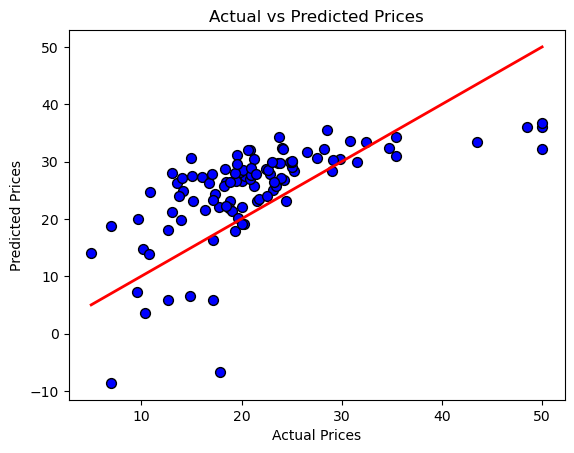

In [7]:
# 일부 feature를 사용하여 2D로 시각화
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=50)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()


## 과제 1-1 : epsilon 값을 변경하면서 LinearSVR을 적합한 후, 결과를 확인하고 이유를 분석해주세요!

성능 평가 후 평가지표와 그래프를 사용해서 분석해주세요

In [11]:
# 모델 생성
svr = LinearSVR(epsilon=3) # Todo


# 모델 훈련
svr.fit(X_train, y_train)


LinearSVR(epsilon=3)

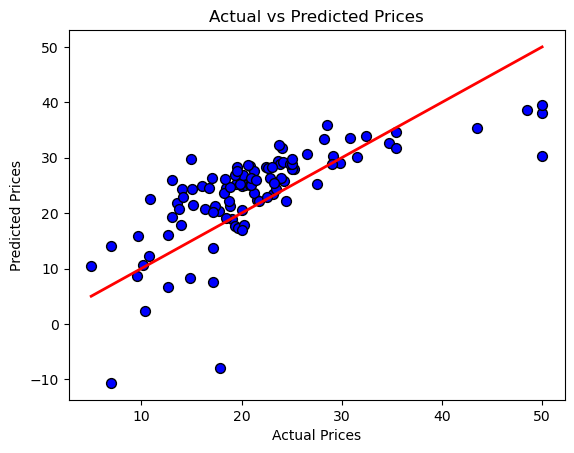

In [12]:
# 일부 feature를 사용하여 2D로 시각화
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=50)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()


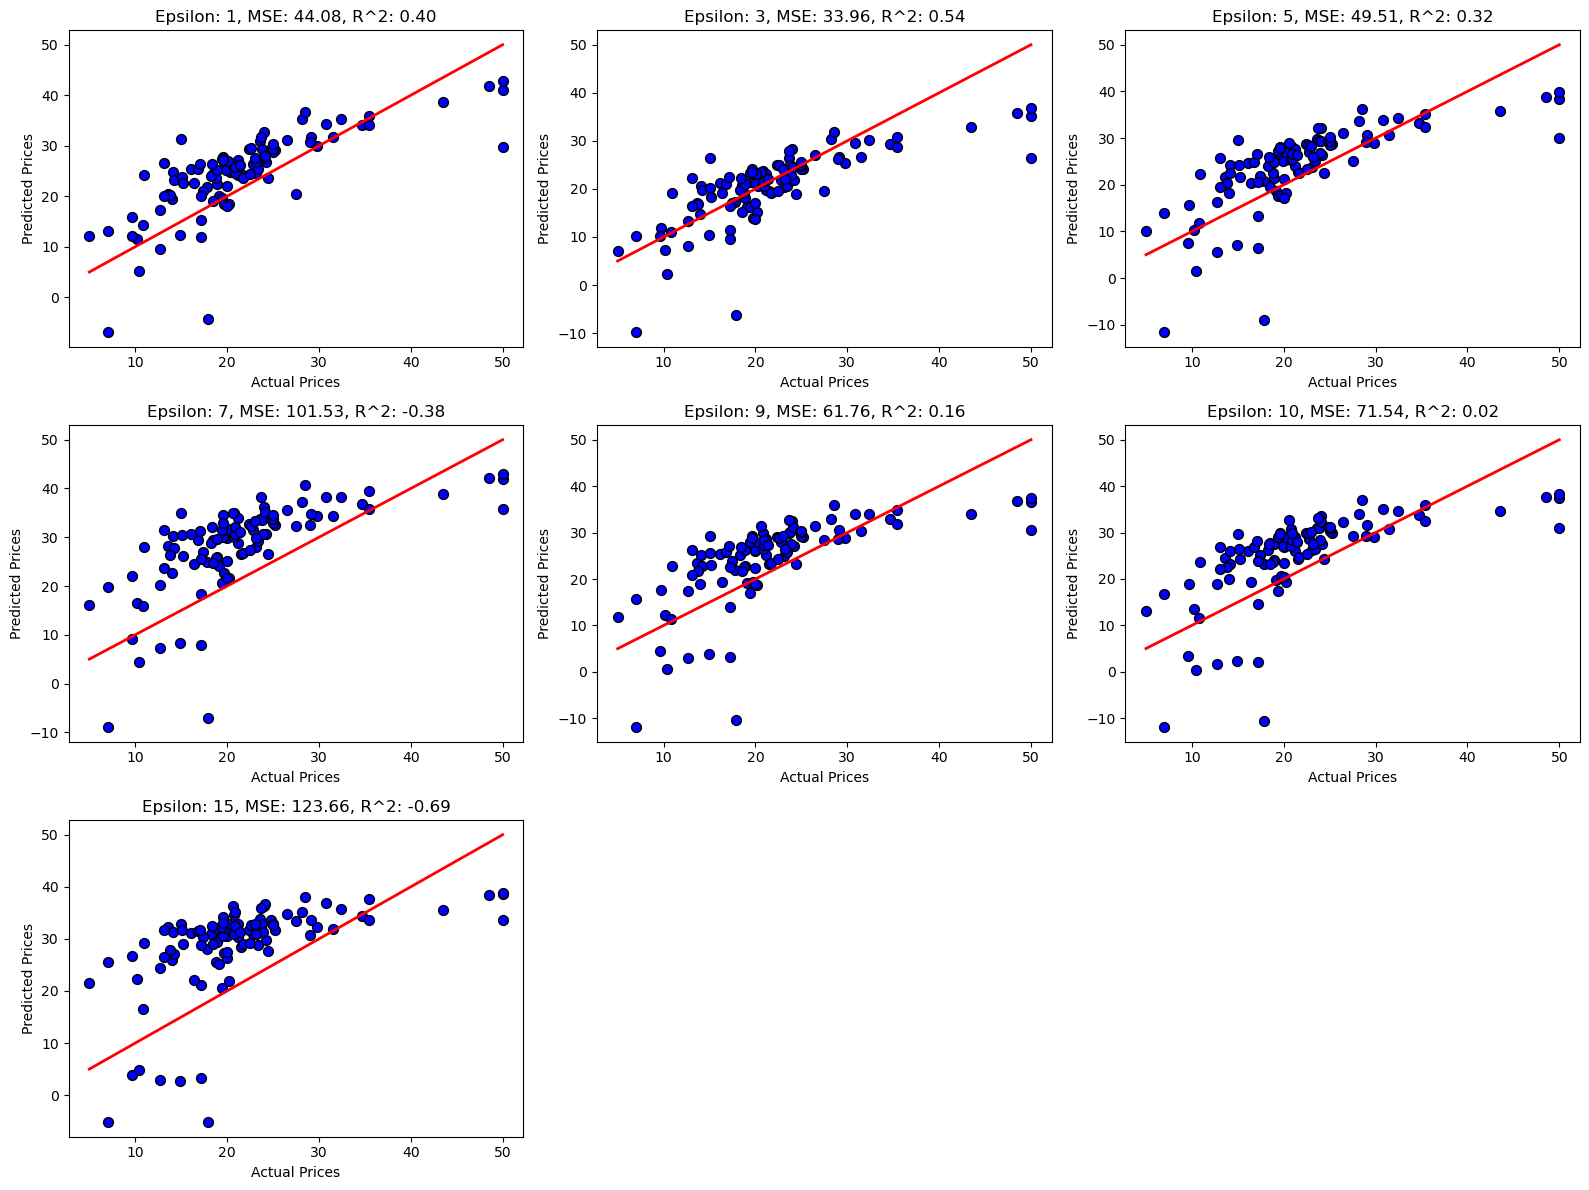

Epsilon: 1, MSE: 44.07945779426455, R^2: 0.3989201716499795
Epsilon: 3, MSE: 33.95698606855143, R^2: 0.53695303030645
Epsilon: 5, MSE: 49.51400525048566, R^2: 0.32481316091060364
Epsilon: 7, MSE: 101.52936898453675, R^2: -0.3844829028194596
Epsilon: 9, MSE: 61.76202430503705, R^2: 0.1577957437432025
Epsilon: 10, MSE: 71.54252162027434, R^2: 0.024426143897861352
Epsilon: 15, MSE: 123.66336083898679, R^2: -0.686308213073269


In [14]:
# Todo

# epsilon 값들 설정
epsilons = [1, 3, 5, 7, 9, 10, 15]
mse_scores = []
r2_scores = []

# 그래프 크기 설정
plt.figure(figsize=(16, 12))

# 각 epsilon 값에 대해 모델 훈련 및 성능 평가
for i, epsilon in enumerate(epsilons):
    svr = LinearSVR(epsilon=epsilon)  # epsilon 값 설정
    svr.fit(X_train, y_train)  # 모델 훈련
    
    # 예측값 계산
    y_pred = svr.predict(X_test)
    
    # 성능 평가
    mse = mean_squared_error(y_test, y_pred)  # MSE 계산
    r2 = r2_score(y_test, y_pred)  # R^2 점수 계산
    
    mse_scores.append(mse)
    r2_scores.append(r2)
    
    # 각 epsilon 값에 대한 Actual vs Predicted 그래프 그리기
    plt.subplot(3, 3, i + 1)  # 3x3 그리드에 배치
    plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=50)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.title(f'Epsilon: {epsilon}, MSE: {mse:.2f}, R^2: {r2:.2f}')

# 전체 레이아웃 조정
plt.tight_layout()
plt.show()

# epsilon에 따른 성능 출력
for epsilon, mse, r2 in zip(epsilons, mse_scores, r2_scores):
    print(f"Epsilon: {epsilon}, MSE: {mse}, R^2: {r2}")


### 분석 결과: epsilon 값들을 여러 개 설정해서 실험해 본 결과, MSE 값이 작고, R^2 값이 큰 Epsilon: 3이 가장 성능이 좋은 모델이었다. epsilon이 작아질수록 모델이 예측값을 실제 값에 가까운 범위로 맞추려는 경향이 있어, 훈련 데이터와 테스트 데이터 모두에서 더 나은 성능을 낼 수 있었던 것 같다. 

# 과제 1-2 : SVM 분류

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')


In [16]:
# 데이터 로드
iris = load_iris()
X, y = iris.data, iris.target

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 과제 1 - 2 trade-off 파라미터 C 값 설정

아래 수식처럼 C가 동작하는데, C가 작을수록 에러가 생겨도 가중치가 작기에 오버피팅을 막을 수 있음.

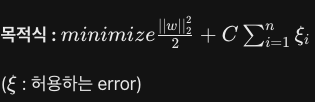


In [17]:
# 다양한 trade-off 파라미터 C 값 설정
C_values = [0.01, 0.1,1,5,10,20] # Todo
train_accuracies = []
test_accuracies = []

for C in C_values:
    # 모델 생성
    svc = LinearSVC(C=C)

    # 모델 훈련
    svc.fit(X_train, y_train)

    # 훈련 데이터와 테스트 데이터에 대한 예측
    y_train_pred = svc.predict(X_train)
    y_test_pred = svc.predict(X_test)

    # 정확도 계산
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # 결과 저장
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # 성능 출력
    print(f"C={C}:")
    print(f"Training Accuracy: {train_acc}")
    print(f"Testing Accuracy: {test_acc}")
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")
    print("-" * 50)


C=0.01:
Training Accuracy: 0.8
Testing Accuracy: 0.8333333333333334
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.44      0.62         9
           2       0.69      1.00      0.81        11

    accuracy                           0.83        30
   macro avg       0.90      0.81      0.81        30
weighted avg       0.89      0.83      0.82        30

--------------------------------------------------
C=0.1:
Training Accuracy: 0.9666666666666667
Testing Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

------

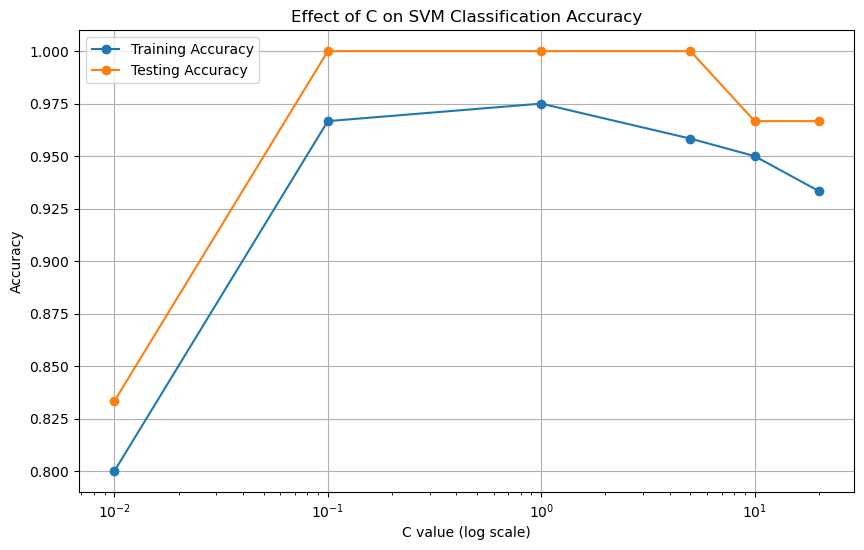

In [18]:
# C 값에 따른 정확도 시각화
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(C_values, test_accuracies, marker='o', label='Testing Accuracy')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of C on SVM Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()


### 분석 결과: 가장 성능이 좋은 값은 C=1이다. 이 값은 고른 성능을 보이며, 훈련 데이터와 테스트 데이터 모두에서 정확도 1.0을 달성하고 있다. 
### C 값이 작아질수록 과소적합될 확률이 높아지고, C 값이 커질수록 과적합될 확률이 높아진다. C=1이 적절한 균형을 유지하고 있다.